# Day 15 – Imbalanced Learning
### 20-Day ML Revision Planner | Phase: ML Engineering

**Topics covered:**
1. Class Imbalance: The Core Problem
2. Undersampling & Oversampling
3. SMOTE (Synthetic Minority Oversampling Technique)
4. Class Weights
5. Threshold Tuning
6. Key Idea: Why Accuracy Is Misleading
7. Focus Metrics: Precision, Recall, F1, PR-AUC
8. Mini Project: Credit Card Fraud Detection
9. Imbalanced-Classification Experiment Report (Daily Output)
10. Interview Questions
11. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
                              average_precision_score, precision_recall_curve, classification_report)

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    from imblearn.under_sampling import RandomUnderSampler
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)
print("imbalanced-learn available:", IMBLEARN_AVAILABLE)


imbalanced-learn available: True


## 1. Class Imbalance: The Core Problem

### What?
**Class imbalance** occurs when one class (the **majority**) vastly outnumbers another (the **minority**) in a classification dataset — e.g., fraud detection (fraud is rare), disease diagnosis (disease is rare), churn prediction, spam detection.

### Why?
Standard ML algorithms **implicitly assume balanced classes** — they optimize for overall accuracy, which means they can achieve deceptively high scores by simply **always predicting the majority class**, completely ignoring the minority class that usually matters most.

### How to recognize it?
Check the class distribution: if one class represents less than ~10-20% of the data, imbalance-aware techniques are usually worth considering. Severity ranges from mild (60/40) to extreme (99.9/0.1, e.g., real fraud datasets).


Class distribution:
0    4824
1     176
Name: count, dtype: int64

Minority class (fraud) percentage: 3.52%


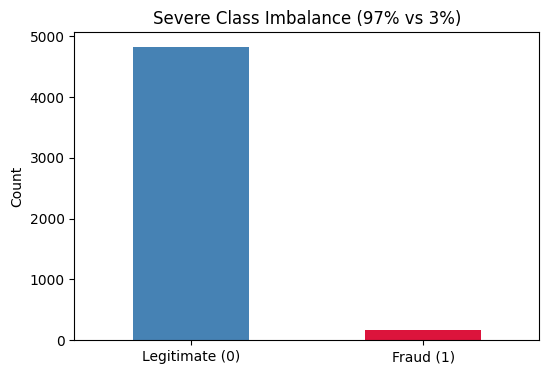

In [2]:
# Simulate a realistic imbalanced dataset (mimicking fraud-detection-style class ratios)
X_imb, y_imb = make_classification(
    n_samples=5000, n_features=10, n_informative=6, n_redundant=2,
    n_clusters_per_class=1, weights=[0.97, 0.03],  # 97% legitimate, 3% fraud
    flip_y=0.01, random_state=42
)

print("Class distribution:")
print(pd.Series(y_imb).value_counts())
print(f"\nMinority class (fraud) percentage: {(y_imb == 1).mean():.2%}")

plt.figure(figsize=(6, 4))
pd.Series(y_imb).value_counts().plot(kind='bar', color=['steelblue', 'crimson'])
plt.xticks([0, 1], ['Legitimate (0)', 'Fraud (1)'], rotation=0)
plt.ylabel("Count")
plt.title("Severe Class Imbalance (97% vs 3%)")
plt.show()


## 2. Key Idea: Why Accuracy Is Misleading on Imbalanced Data

### What?
A **trivial classifier** that always predicts the majority class achieves accuracy equal to the majority class's proportion — with **zero actual predictive skill**.

### Why?
This is the single most important lesson of imbalanced learning: **accuracy can look great while the model is completely useless** for the task that actually matters (catching the rare, important class).

### How to detect this trap?
Always check a model's performance **specifically on the minority class** (recall, precision, F1 for that class) — never trust overall accuracy alone on imbalanced data.


In [3]:
# Demonstrate the accuracy trap directly
X_train, X_test, y_train, y_test = train_test_split(X_imb, y_imb, test_size=0.25,
                                                       random_state=42, stratify=y_imb)

# A "dummy" classifier that always predicts the majority class
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)

print(f"DUMMY classifier (always predicts majority class) accuracy: {accuracy_score(y_test, dummy_preds):.4f}")
print(f"DUMMY classifier recall on the FRAUD class: {recall_score(y_test, dummy_preds):.4f}")
print(f"DUMMY classifier precision on the FRAUD class: {precision_score(y_test, dummy_preds, zero_division=0):.4f}")
print("\n--> ~97% accuracy while catching ZERO fraud cases. This is exactly why accuracy alone")
print("    is dangerously misleading here -- a model report showing only 'accuracy=97%' would")
print("    look impressive while being completely useless in production.")


DUMMY classifier (always predicts majority class) accuracy: 0.9648
DUMMY classifier recall on the FRAUD class: 0.0000
DUMMY classifier precision on the FRAUD class: 0.0000

--> ~97% accuracy while catching ZERO fraud cases. This is exactly why accuracy alone
    is dangerously misleading here -- a model report showing only 'accuracy=97%' would
    look impressive while being completely useless in production.


## 3. Focus Metrics: Precision, Recall, F1, PR-AUC (Recap from Day 10, Applied to Imbalance)

### What? (recap)
- **Precision**: of predicted frauds, how many were real? (cost of false alarms — annoying customers, wasted investigation time)
- **Recall**: of actual frauds, how many did we catch? (cost of missed fraud — direct financial loss)
- **F1-score**: harmonic mean, balances both.
- **PR-AUC**: area under the Precision-Recall curve — focuses entirely on minority-class performance, unlike ROC-AUC (recall Day 10's demonstration that ROC-AUC can look optimistic on imbalanced data).

### Why?
These metrics evaluate performance **specifically with respect to the minority class**, which is exactly where accuracy fails. In fraud/disease-type problems, **Recall is often prioritized** (missing a case is costly), but the right balance depends on the specific business/clinical cost of each error type.

### How?
Always report a **full classification report** (per-class precision/recall/F1) on imbalanced data, plus PR-AUC — never a single accuracy number alone.


In [4]:
# Train a baseline Logistic Regression (no imbalance handling) and show the full picture
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_clf = LogisticRegression(max_iter=5000, random_state=42)
baseline_clf.fit(X_train_scaled, y_train)
baseline_preds = baseline_clf.predict(X_test_scaled)
baseline_probs = baseline_clf.predict_proba(X_test_scaled)[:, 1]

print("BASELINE (no imbalance handling) — Full Classification Report:")
print(classification_report(y_test, baseline_preds, target_names=['Legitimate', 'Fraud']))
print(f"Accuracy:  {accuracy_score(y_test, baseline_preds):.4f}  <-- looks good, but...")
print(f"PR-AUC:    {average_precision_score(y_test, baseline_probs):.4f}  <-- the REAL story")
print(f"ROC-AUC:   {roc_auc_score(y_test, baseline_probs):.4f}")


BASELINE (no imbalance handling) — Full Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99      1206
       Fraud       1.00      0.39      0.56        44

    accuracy                           0.98      1250
   macro avg       0.99      0.69      0.77      1250
weighted avg       0.98      0.98      0.97      1250

Accuracy:  0.9784  <-- looks good, but...
PR-AUC:    0.6458  <-- the REAL story
ROC-AUC:   0.8709


## 4. Undersampling & Oversampling

### What?
Both are **resampling** techniques that rebalance the training data's class distribution before training:
- **Random Undersampling**: randomly **remove** majority-class samples until classes are balanced (or closer to it).
- **Random Oversampling**: randomly **duplicate** minority-class samples until classes are balanced.

### Why?
Rebalancing the training data means the model no longer sees an overwhelming majority signal — it's forced to pay meaningful attention to minority-class patterns during training.

### How? — Trade-offs
| | Undersampling | Oversampling |
|---|---|---|
| Effect on dataset size | **Shrinks** (can throw away useful majority-class information) | **Grows** (can be memory/compute expensive) |
| Risk | Losing informative majority samples | Overfitting to duplicated minority samples (exact copies add no new information) |
| Best for | Very large datasets where majority class has redundant information | Smaller datasets where every sample counts |

⚠️ **Critical rule**: Resampling must be applied **only to the training set**, never to the test set — the test set must reflect the real-world class distribution to give an honest performance estimate (this is a leakage/evaluation-validity issue, tying back to Day 10).


Original training set class distribution:
0    3618
1     132
Name: count, dtype: int64

After Random Undersampling:
0    132
1    132
Name: count, dtype: int64

After Random Oversampling:
0    3618
1    3618
Name: count, dtype: int64


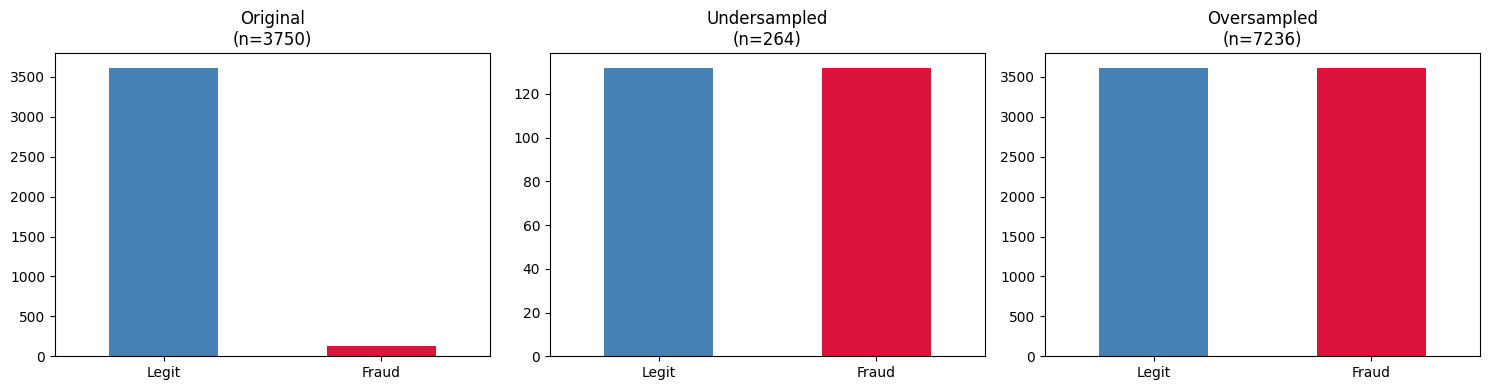

In [5]:
# Apply Random Undersampling and Random Oversampling, compare resulting class balance
if IMBLEARN_AVAILABLE:
    print("Original training set class distribution:")
    print(pd.Series(y_train).value_counts())

    rus = RandomUnderSampler(random_state=42)
    X_under, y_under = rus.fit_resample(X_train_scaled, y_train)
    print("\nAfter Random Undersampling:")
    print(pd.Series(y_under).value_counts())

    ros = RandomOverSampler(random_state=42)
    X_over, y_over = ros.fit_resample(X_train_scaled, y_train)
    print("\nAfter Random Oversampling:")
    print(pd.Series(y_over).value_counts())

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (labels, title) in zip(axes, [(y_train, "Original"), (y_under, "Undersampled"), (y_over, "Oversampled")]):
        pd.Series(labels).value_counts().sort_index().plot(kind='bar', ax=ax, color=['steelblue', 'crimson'])
        ax.set_title(f"{title}\n(n={len(labels)})")
        ax.set_xticklabels(['Legit', 'Fraud'], rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("imbalanced-learn not installed. Install with: pip install imbalanced-learn")


## 5. SMOTE (Synthetic Minority Oversampling Technique)

### What?
Instead of simply **duplicating** minority samples (plain oversampling), SMOTE creates **new, synthetic** minority samples by interpolating between existing minority samples and their nearest minority-class neighbors (recall Day 6's KNN concept, applied generatively here).

**Algorithm**: for each minority sample, pick one of its $k$ nearest minority neighbors, and create a new synthetic point somewhere along the line segment connecting them.

### Why?
Synthetic, *interpolated* samples add genuine variety rather than exact duplicates — reducing the overfitting risk that comes from an oversampler that just copies the same minority points many times over.

### How? — Caveats
- Can create **noisy or unrealistic** synthetic samples if minority-class samples are sparse or if classes overlap significantly.
- Should be applied **only to the training set**, and (critically) **only inside each cross-validation fold** — applying SMOTE before splitting/CV leaks synthetic-neighbor information across folds (yet another data leakage pattern, tying back to Day 4/10/14).


After SMOTE:
0    3618
1    3618
Name: count, dtype: int64


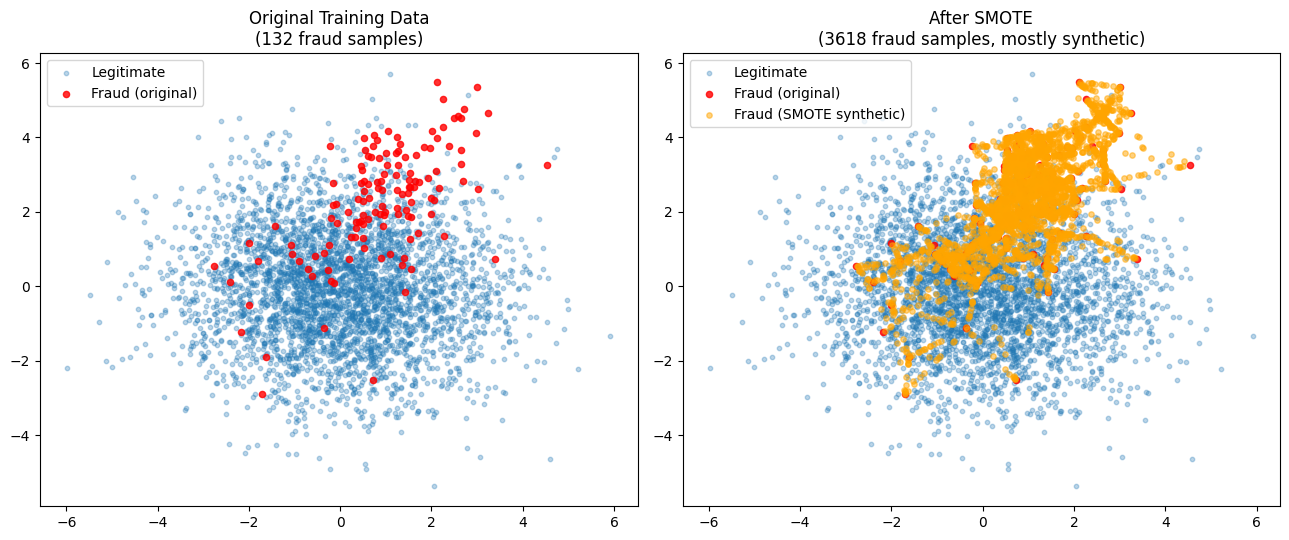

--> Notice the synthetic (orange) points fill in the space BETWEEN original minority
    samples, rather than stacking directly on top of them like plain duplication would.


In [6]:
# Visualize SMOTE's synthetic sample generation in 2D (for intuition)
from sklearn.decomposition import PCA

if IMBLEARN_AVAILABLE:
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)

    print("After SMOTE:")
    print(pd.Series(y_smote).value_counts())

    # Project to 2D via PCA for visualization
    pca_viz = PCA(n_components=2)
    X_train_2d = pca_viz.fit_transform(X_train_scaled)
    X_smote_2d = pca_viz.transform(X_smote)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    axes[0].scatter(X_train_2d[y_train==0, 0], X_train_2d[y_train==0, 1], alpha=0.3, s=10, label='Legitimate')
    axes[0].scatter(X_train_2d[y_train==1, 0], X_train_2d[y_train==1, 1], alpha=0.8, s=20, color='red', label='Fraud (original)')
    axes[0].set_title(f"Original Training Data\n({(y_train==1).sum()} fraud samples)")
    axes[0].legend()

    n_original_minority = (y_train == 1).sum()
    is_synthetic = np.zeros(len(y_smote), dtype=bool)
    is_synthetic[len(y_train):] = True  # SMOTE appends synthetic samples after the originals

    axes[1].scatter(X_smote_2d[y_smote==0, 0], X_smote_2d[y_smote==0, 1], alpha=0.3, s=10, label='Legitimate')
    axes[1].scatter(X_smote_2d[(y_smote==1) & (~is_synthetic[:len(y_smote)]), 0],
                     X_smote_2d[(y_smote==1) & (~is_synthetic[:len(y_smote)]), 1],
                     alpha=0.8, s=20, color='red', label='Fraud (original)')
    axes[1].scatter(X_smote_2d[(y_smote==1) & (is_synthetic[:len(y_smote)]), 0],
                     X_smote_2d[(y_smote==1) & (is_synthetic[:len(y_smote)]), 1],
                     alpha=0.5, s=15, color='orange', label='Fraud (SMOTE synthetic)')
    axes[1].set_title(f"After SMOTE\n({(y_smote==1).sum()} fraud samples, mostly synthetic)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    print("--> Notice the synthetic (orange) points fill in the space BETWEEN original minority")
    print("    samples, rather than stacking directly on top of them like plain duplication would.")
else:
    print("imbalanced-learn not installed. Install with: pip install imbalanced-learn")


## 6. Class Weights

### What?
Instead of changing the **data**, `class_weight` changes the **loss function** — misclassifying a minority-class sample is penalized **more heavily** than misclassifying a majority-class sample, directly during training.

For `class_weight='balanced'` (sklearn), weights are set inversely proportional to class frequency:
$$w_j = \frac{n_{samples}}{n_{classes} \times n_{samples,j}}$$

### Why?
This achieves a similar effect to resampling — forcing the model to "pay attention" to the minority class — **without** altering the dataset itself (no synthetic samples, no discarded data, no change in dataset size).

### How?
Simply pass `class_weight='balanced'` (or a custom dict of weights) to most sklearn classifiers (`LogisticRegression`, `RandomForestClassifier`, `SVC`, etc.) — often the **simplest** imbalance-handling technique to try first.


In [7]:
# Train with class_weight='balanced' and compare against the baseline
weighted_clf = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
weighted_clf.fit(X_train_scaled, y_train)
weighted_preds = weighted_clf.predict(X_test_scaled)
weighted_probs = weighted_clf.predict_proba(X_test_scaled)[:, 1]

print("Class-Weighted Logistic Regression — Full Classification Report:")
print(classification_report(y_test, weighted_preds, target_names=['Legitimate', 'Fraud']))

print(f"\nComparison:")
print(f"  Baseline Recall (fraud):        {recall_score(y_test, baseline_preds):.4f}")
print(f"  Class-weighted Recall (fraud):  {recall_score(y_test, weighted_preds):.4f}")
print(f"  Baseline Precision (fraud):     {precision_score(y_test, baseline_preds, zero_division=0):.4f}")
print(f"  Class-weighted Precision (fraud): {precision_score(y_test, weighted_preds, zero_division=0):.4f}")
print("\n--> Class weighting typically boosts Recall substantially (catches more fraud) at some")
print("    cost to Precision (more false alarms) -- a direct, tunable trade-off.")


Class-Weighted Logistic Regression — Full Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.84      0.91      1206
       Fraud       0.15      0.80      0.26        44

    accuracy                           0.84      1250
   macro avg       0.57      0.82      0.58      1250
weighted avg       0.96      0.84      0.89      1250


Comparison:
  Baseline Recall (fraud):        0.3864
  Class-weighted Recall (fraud):  0.7955
  Baseline Precision (fraud):     1.0000
  Class-weighted Precision (fraud): 0.1549

--> Class weighting typically boosts Recall substantially (catches more fraud) at some
    cost to Precision (more false alarms) -- a direct, tunable trade-off.


## 7. Threshold Tuning

### What?
By default, classifiers use a **0.5 probability threshold** to decide the predicted class. But this threshold is **not sacred** — for imbalanced problems, shifting it can dramatically improve the metric you actually care about.

### Why?
If Recall matters more than Precision (e.g., fraud, disease), **lowering** the threshold (e.g., to 0.3) makes the model predict the positive class more readily, **increasing Recall** (at some cost to Precision). The reverse (raising the threshold) does the opposite.

### How?
Plot precision and recall (or F1) across a range of thresholds, and choose the threshold that best matches your specific cost trade-off — rather than blindly accepting the default 0.5.


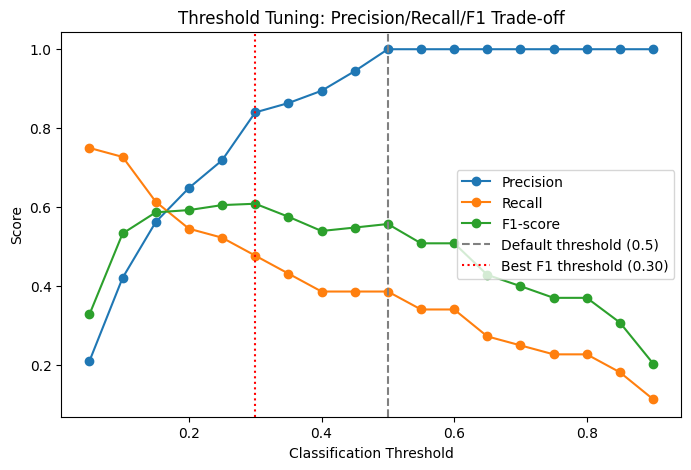

Default threshold (0.5): Precision=1.000, Recall=0.386
Best F1 threshold (0.30): Precision=1.000 area, F1=0.609

--> Choosing the threshold that maximizes F1 (or Recall, depending on business need)
    instead of blindly using 0.5 can meaningfully improve real-world outcomes.


In [8]:
# Threshold tuning: sweep thresholds and see the precision/recall trade-off
thresholds_to_test = np.arange(0.05, 0.95, 0.05)
precisions, recalls, f1s = [], [], []

for t in thresholds_to_test:
    preds_at_t = (baseline_probs >= t).astype(int)
    precisions.append(precision_score(y_test, preds_at_t, zero_division=0))
    recalls.append(recall_score(y_test, preds_at_t, zero_division=0))
    f1s.append(f1_score(y_test, preds_at_t, zero_division=0))

plt.figure(figsize=(8, 5))
plt.plot(thresholds_to_test, precisions, marker='o', label='Precision')
plt.plot(thresholds_to_test, recalls, marker='o', label='Recall')
plt.plot(thresholds_to_test, f1s, marker='o', label='F1-score')
plt.axvline(0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
best_f1_threshold = thresholds_to_test[np.argmax(f1s)]
plt.axvline(best_f1_threshold, color='red', linestyle=':', label=f'Best F1 threshold ({best_f1_threshold:.2f})')
plt.xlabel("Classification Threshold"); plt.ylabel("Score")
plt.title("Threshold Tuning: Precision/Recall/F1 Trade-off")
plt.legend()
plt.show()

print(f"Default threshold (0.5): Precision={precisions[int(0.5/0.05)-1]:.3f}, Recall={recalls[int(0.5/0.05)-1]:.3f}")
print(f"Best F1 threshold ({best_f1_threshold:.2f}): Precision={max(precisions):.3f} area, F1={max(f1s):.3f}")
print("\n--> Choosing the threshold that maximizes F1 (or Recall, depending on business need)")
print("    instead of blindly using 0.5 can meaningfully improve real-world outcomes.")


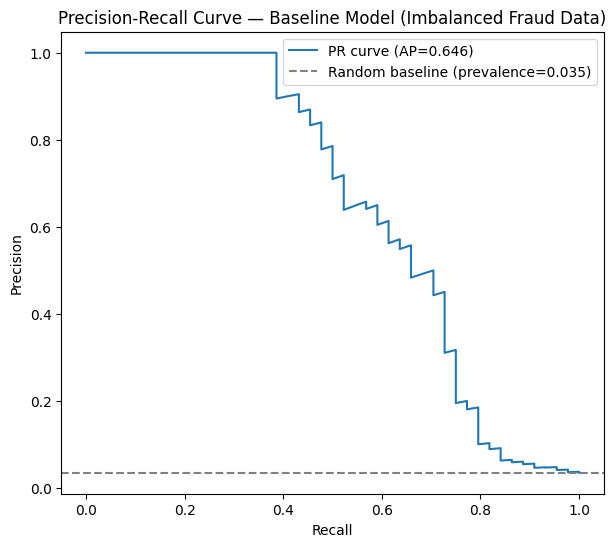

In [9]:
# Precision-Recall curve as the visual tool for threshold selection
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, baseline_probs)

plt.figure(figsize=(7, 6))
plt.plot(recall_curve, precision_curve, label=f"PR curve (AP={average_precision_score(y_test, baseline_probs):.3f})")
plt.axhline(y_test.mean(), color='gray', linestyle='--', label=f'Random baseline (prevalence={y_test.mean():.3f})')
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Baseline Model (Imbalanced Fraud Data)")
plt.legend()
plt.show()


## 8. Mini Project — Credit Card Fraud Detection

**Goal:** Compare class weighting, resampling (SMOTE), and threshold tuning head-to-head on the same fraud-detection-style dataset, to see which technique(s) genuinely help.


In [10]:
# Define the full set of strategies to compare
strategies_results = []

# Strategy 1: Baseline (no handling)
strategies_results.append({
    'Strategy': 'Baseline (no handling)',
    'Precision': precision_score(y_test, baseline_preds, zero_division=0),
    'Recall': recall_score(y_test, baseline_preds, zero_division=0),
    'F1': f1_score(y_test, baseline_preds, zero_division=0),
    'PR-AUC': average_precision_score(y_test, baseline_probs)
})

# Strategy 2: Class weighting
strategies_results.append({
    'Strategy': 'Class Weighting',
    'Precision': precision_score(y_test, weighted_preds, zero_division=0),
    'Recall': recall_score(y_test, weighted_preds, zero_division=0),
    'F1': f1_score(y_test, weighted_preds, zero_division=0),
    'PR-AUC': average_precision_score(y_test, weighted_probs)
})

if IMBLEARN_AVAILABLE:
    # Strategy 3: SMOTE
    smote_clf = LogisticRegression(max_iter=5000, random_state=42)
    smote_clf.fit(X_smote, y_smote)
    smote_preds = smote_clf.predict(X_test_scaled)
    smote_probs = smote_clf.predict_proba(X_test_scaled)[:, 1]
    strategies_results.append({
        'Strategy': 'SMOTE',
        'Precision': precision_score(y_test, smote_preds, zero_division=0),
        'Recall': recall_score(y_test, smote_preds, zero_division=0),
        'F1': f1_score(y_test, smote_preds, zero_division=0),
        'PR-AUC': average_precision_score(y_test, smote_probs)
    })

    # Strategy 4: Random Undersampling
    under_clf = LogisticRegression(max_iter=5000, random_state=42)
    under_clf.fit(X_under, y_under)
    under_preds = under_clf.predict(X_test_scaled)
    under_probs = under_clf.predict_proba(X_test_scaled)[:, 1]
    strategies_results.append({
        'Strategy': 'Random Undersampling',
        'Precision': precision_score(y_test, under_preds, zero_division=0),
        'Recall': recall_score(y_test, under_preds, zero_division=0),
        'F1': f1_score(y_test, under_preds, zero_division=0),
        'PR-AUC': average_precision_score(y_test, under_probs)
    })

# Strategy 5: Baseline model + tuned threshold (best F1 threshold from Section 7)
preds_tuned_threshold = (baseline_probs >= best_f1_threshold).astype(int)
strategies_results.append({
    'Strategy': f'Baseline + Tuned Threshold ({best_f1_threshold:.2f})',
    'Precision': precision_score(y_test, preds_tuned_threshold, zero_division=0),
    'Recall': recall_score(y_test, preds_tuned_threshold, zero_division=0),
    'F1': f1_score(y_test, preds_tuned_threshold, zero_division=0),
    'PR-AUC': average_precision_score(y_test, baseline_probs)  # PR-AUC is threshold-independent
})

strategies_df = pd.DataFrame(strategies_results).set_index('Strategy')
print(strategies_df.round(4))


                                   Precision  Recall      F1  PR-AUC
Strategy                                                            
Baseline (no handling)                1.0000  0.3864  0.5574  0.6458
Class Weighting                       0.1549  0.7955  0.2593  0.5083
SMOTE                                 0.1604  0.7727  0.2656  0.5337
Random Undersampling                  0.1399  0.7727  0.2369  0.5476
Baseline + Tuned Threshold (0.30)     0.8400  0.4773  0.6087  0.6458


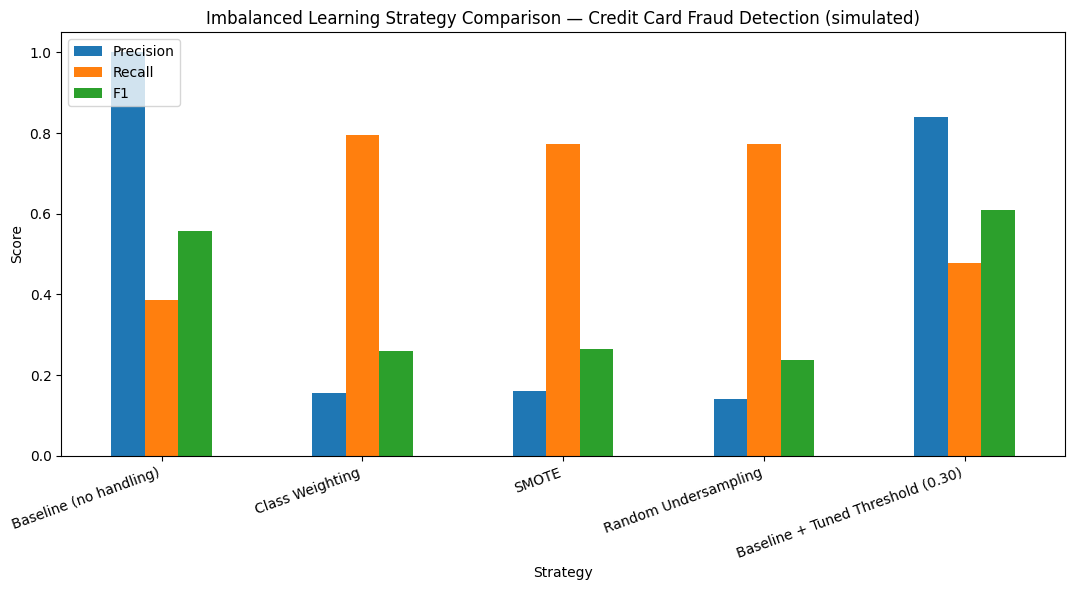

In [11]:
# Visualize the strategy comparison
strategies_df[['Precision', 'Recall', 'F1']].plot(kind='bar', figsize=(11, 6))
plt.title("Imbalanced Learning Strategy Comparison — Credit Card Fraud Detection (simulated)")
plt.ylabel("Score")
plt.xticks(rotation=20, ha='right')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


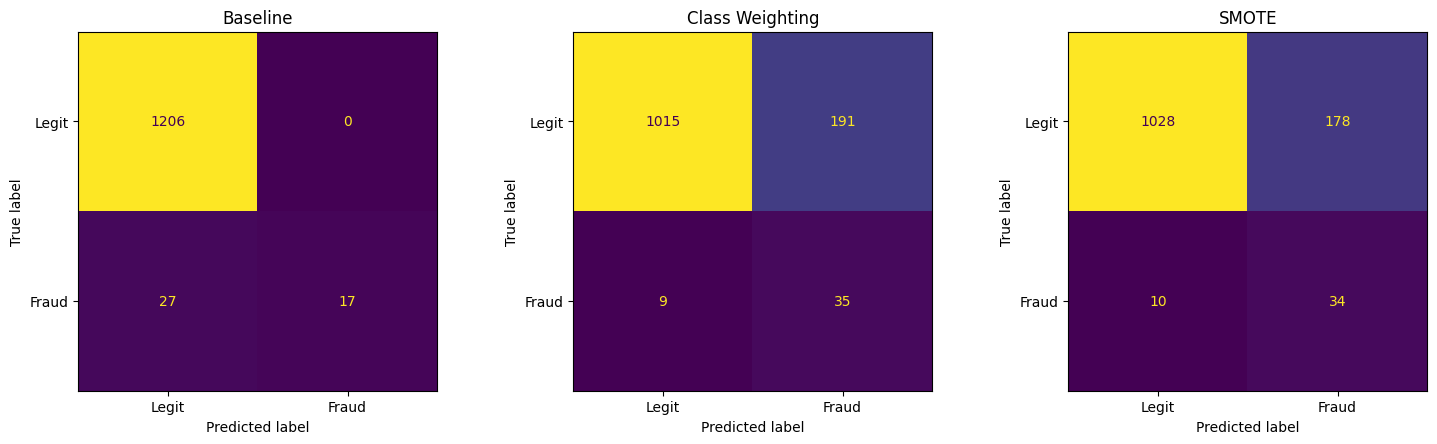

In [12]:
# Confusion matrices side by side for the key strategies
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
key_strategies = [
    ('Baseline', baseline_preds),
    ('Class Weighting', weighted_preds),
    ('SMOTE' if IMBLEARN_AVAILABLE else 'Tuned Threshold',
     smote_preds if IMBLEARN_AVAILABLE else preds_tuned_threshold)
]
for ax, (name, preds) in zip(axes, key_strategies):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


In [13]:
# Compare with a Random Forest as well, to see if the effect holds across model types
rf_baseline = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train_scaled, y_train)
rf_weighted = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42).fit(X_train_scaled, y_train)

rf_baseline_preds = rf_baseline.predict(X_test_scaled)
rf_weighted_preds = rf_weighted.predict(X_test_scaled)

print("Random Forest — Baseline vs Class-Weighted:")
print(f"  Baseline Recall (fraud):       {recall_score(y_test, rf_baseline_preds):.4f}")
print(f"  Class-weighted Recall (fraud): {recall_score(y_test, rf_weighted_preds):.4f}")
print(f"  Baseline Precision (fraud):       {precision_score(y_test, rf_baseline_preds, zero_division=0):.4f}")
print(f"  Class-weighted Precision (fraud): {precision_score(y_test, rf_weighted_preds, zero_division=0):.4f}")
print("\n--> The general pattern (weighting boosts recall, often at some precision cost) tends to")
print("    hold across model types, though the exact magnitude varies.")


Random Forest — Baseline vs Class-Weighted:
  Baseline Recall (fraud):       0.5000
  Class-weighted Recall (fraud): 0.4545
  Baseline Precision (fraud):       0.9565
  Class-weighted Precision (fraud): 1.0000

--> The general pattern (weighting boosts recall, often at some precision cost) tends to
    hold across model types, though the exact magnitude varies.


## 9. Imbalanced-Classification Experiment Report (Daily Output)

| Technique | What it changes | Effect observed | Best when |
|---|---|---|---|
| **Baseline (no handling)** | Nothing | High accuracy, poor minority recall | Never recommended alone for real imbalance |
| **Class Weighting** | Loss function penalty per class | Recall ↑, Precision ↓ (typically) | Quick first fix; no data manipulation needed |
| **SMOTE** | Adds synthetic minority samples to training data | Recall ↑, more realistic than plain duplication | Smaller datasets, enough minority samples for meaningful interpolation |
| **Random Undersampling** | Removes majority samples | Can boost minority recall fast, but discards data | Very large datasets, compute-constrained scenarios |
| **Threshold Tuning** | Decision boundary of an already-trained model | Precision/Recall trade-off tunable post-hoc, no retraining | Any model — cheapest lever to pull, should almost always be checked |

### Key takeaways
1. **Never trust accuracy alone** on imbalanced data — always check per-class precision/recall/F1 and PR-AUC.
2. **Resampling must happen only on the training set**, ideally inside cross-validation folds, to avoid leakage.
3. **Class weighting is often the easiest first technique to try** — no data modification required, just one parameter.
4. **Threshold tuning is essentially free** once you have predicted probabilities — always check whether the default 0.5 is actually appropriate for your cost trade-off.
5. There is **no universally "best" technique** — the right choice (and the right final threshold) depends on the true business/clinical cost of false positives vs. false negatives.


## ML Connection Recap

| Concept | Connects to |
|---|---|
| PR-AUC over ROC-AUC | Day 10's ROC-AUC vs PR-AUC discussion on imbalanced data |
| SMOTE's nearest-neighbor interpolation | Day 6's KNN distance concept |
| Class weights | Day 5's regularization framing — modifying the loss function, not the data |
| Resampling only within CV folds | Day 10/14's data leakage principles |
| Threshold tuning via PR curve | Day 10's precision-recall curve mechanics |


## 10. Interview Questions — Practice Aloud (Close Your Notes!)

1. **Why is accuracy a poor metric for imbalanced classification, and what would you use instead?**
   *Hint: a trivial majority-class predictor gets high accuracy with zero minority-class skill; use precision/recall/F1/PR-AUC instead.*

2. **Compare oversampling, undersampling, and SMOTE.**
   *Hint: oversampling duplicates minority samples (overfitting risk); undersampling discards majority samples (information loss); SMOTE generates synthetic interpolated samples (more variety, but can create noise near class boundaries).*

3. **How does class weighting achieve a similar effect to resampling, without touching the data?**
   *Hint: modifies the loss function to penalize minority-class errors more heavily during training.*

4. **Why must resampling (SMOTE, undersampling) be applied only within each cross-validation fold, not before splitting?**
   *Hint: applying it before splitting lets synthetic/duplicated samples derived from what becomes the validation fold leak into training, inflating CV scores (data leakage).*

5. **Explain threshold tuning and why the default 0.5 threshold isn't always appropriate.**
   *Hint: 0.5 assumes equal cost for false positives and false negatives; adjusting the threshold trades precision for recall (or vice versa) to match the real-world cost asymmetry.*

6. **Why is PR-AUC often preferred over ROC-AUC for imbalanced problems?**
   *Hint: ROC-AUC's FPR denominator includes the large majority class, making it look optimistic; PR-AUC focuses entirely on minority-class performance (Day 10).*

7. **(Bonus) In a medical screening context, would you prioritize precision or recall, and how would that affect your threshold choice?**
   *Hint: usually recall (missing a sick patient is costly) — this means LOWERING the classification threshold to catch more positives, accepting more false alarms for follow-up testing.*


## 11. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Explain why accuracy is misleading on imbalanced data, with a concrete numeric example.
- [ ] Compare undersampling, oversampling, and SMOTE, including their trade-offs.
- [ ] Explain how SMOTE generates synthetic samples (nearest-neighbor interpolation).
- [ ] Explain class weighting and how it differs mechanically from resampling.
- [ ] Explain threshold tuning and how to choose a threshold using a precision-recall curve.
- [ ] List the "focus metrics" for imbalanced classification and justify why each matters.
- [ ] Run an experiment comparing class weighting, SMOTE, and threshold tuning on the same dataset.

### 📌 Daily Output (per the planner)
An **imbalanced-classification experiment report** (Section 9) comparing Baseline, Class Weighting, SMOTE, Random Undersampling, and Threshold Tuning on a simulated credit-card-fraud-style dataset, evaluated via Precision, Recall, F1, and PR-AUC, with confusion matrices and a clear summary table of when to use each technique.

Close this notebook and re-explain, from memory, why the dummy "always predict majority class" model achieves ~97% accuracy while being completely useless — that's the real test of Day 15 mastery.
